In [497]:
import os

# Import modules and add library to path
import sys

os.environ[
    "CUDA_VISIBLE_DEVICES"] = "0"  # Change to os.environ["CUDA_VISIBLE_DEVICES"] = "" if you dont have access to a GPU
import pickle

import numpy as np
import pandas as pd

# Initialize plotly figures
from plotly.offline import init_notebook_mode
from tensorflow.keras.backend import clear_session

# DeepMReye imports
from deepmreye import analyse, architecture, preprocess, train
from deepmreye.util import data_generator, model_opts, util

init_notebook_mode(connected=True)

# Make sure the output width is adjusted for better export as HTML
from IPython.core.display import HTML, display

display(HTML("<style>.container { width:70% !important; }</style>"))
display(HTML("<style>.output_result { max-width:70% !important; }</style>"))

# Autoreload modules
%load_ext autoreload
%autoreload 2

/net/tscratch/people/plgkoba/slurm_jobdir/1830004/tmp.t0033/ipykernel_1441171/3163588531.py:24: DeprecationWarning:

Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython.display



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Preprocessing

In [505]:
functional_data = 'stroke_dataset'

# Get participants from functional folder
# (if needed, remove single participants with participants.remove('participant01') or recreate participants list)
participants = os.listdir(functional_data)

# Preload masks to save time within participant loop
(
    eyemask_small,
    eyemask_big,
    dme_template,
    mask,
    x_edges,
    y_edges,
    z_edges,
) = preprocess.get_masks()

# Loop across participants and extract eye mask
for participant in participants:
    if participant.startswith("s"):
        print("Running participant {}".format(participant))
        participant_folder = os.path.join(functional_data, participant)
        for run in os.listdir(participant_folder):
            
            # Filepath to functional
            fp_func = os.path.join(participant_folder, run)
            print(fp_func)
            preprocess.run_participant(
                fp_func,
                dme_template,
                eyemask_big,
                eyemask_small,
                x_edges,
                y_edges,
                z_edges,
            )

Running participant sub-CON014
stroke_dataset/sub-CON014/sub-CON014_ses-control2_task-rest_run-0_bold.nii.gz
Mask 0/2, Sum: -59.635, Mean -4.970, Std 10.700, Median -0.007
Mask 1/2, Sum: -1.039, Mean -0.087, Std 1.708, Median 0.024
Mask 2/2, Sum: -7.334, Mean -0.611, Std 2.440, Median 0.010
Running participant sub-CON011
stroke_dataset/sub-CON011/sub-CON011_ses-control2_task-rest_run-0_bold.nii.gz
Mask 0/2, Sum: -43.126, Mean -3.594, Std 9.158, Median -0.001
Mask 1/2, Sum: 1.715, Mean 0.143, Std 2.518, Median 0.065
Mask 2/2, Sum: -3.322, Mean -0.277, Std 1.872, Median 0.002
Running participant sub-CON010
stroke_dataset/sub-CON010/sub-CON010_ses-control2_task-rest_run-0_bold.nii.gz
Mask 0/2, Sum: -42.038, Mean -3.503, Std 9.874, Median 0.008
Mask 1/2, Sum: -1.235, Mean -0.103, Std 1.916, Median 0.012
Mask 2/2, Sum: 1.060, Mean 0.088, Std 1.309, Median 0.018
Running participant sub-CON004
stroke_dataset/sub-CON004/sub-CON004_ses-control2_task-rest_run-0_bold.nii.gz
Mask 0/2, Sum: -54.309

In [506]:
# Combine processed masks with labels
for participant in participants:

    if participant.startswith("s"):

        print("Running participant {}".format(participant))

        participant_folder = os.path.join(functional_data, participant)

        participant_data, participant_data_left, participant_data_right, participant_labels = [], [], [], []
        participant_ids,participant_ids_left,participant_ids_right =  [], [], []
        
        # Create left and right labels
        participant_left = f"{participant}_left"
        participant_right = f"{participant}_right"

        # Store in dictionaries
        participants_left[participant] = participant_left
        participants_right[participant] = participant_right

        for run_idx, run in enumerate(os.listdir(participant_folder)):
            if not run.endswith(".p"):
                continue
            # Load mask and normalize it
            this_mask = os.path.join(participant_folder, run)
            this_mask = pickle.load(open(this_mask, "rb"))
            this_mask = preprocess.normalize_img(this_mask)
            this_mask_left=this_mask[:24,:,:,:]
            this_mask_right=this_mask[24:,:,:,:]

            # Load labels (in visual angle)
            this_label = np.zeros((this_mask.shape[3],10,2))

            # Check if each functional image has a corresponding label. Note that mask has time as third dimension
            if not this_mask.shape[3] == this_label.shape[0]:
                print(
                    "WARNING --- Skipping Subject {} Run {} --- Wrong alignment (Mask {} - Label {})."
                    .format(participant, run_idx, this_mask.shape,
                            this_label.shape))
                continue

            # Store across runs
            participant_data.append(this_mask)
            participant_data_left.append(this_mask_left)
            participant_data_right.append(this_mask_right)
            participant_labels.append(this_label)
            participant_ids.append(([participant] * this_label.shape[0],
                                    [run_idx] * this_label.shape[0]))
            participant_ids_left.append(([participant_left] * this_label.shape[0],
                                    [run_idx] * this_label.shape[0]))
            participant_ids_right.append(([participant_right] * this_label.shape[0],
                                    [run_idx] * this_label.shape[0]))

        # Save participant file
        preprocess.save_data(
            participant,
            participant_data,
            participant_labels,
            participant_ids,
            functional_data,
            center_labels=False,
        )

        preprocess.save_data(
            participant_left,
            participant_data_left,
            participant_labels,
            participant_ids_left,
            functional_data,
            center_labels=False,
        )

        preprocess.save_data(
            participant_right,
            participant_data_right,
            participant_labels,
            participant_ids_right,
            functional_data,
            center_labels=False,
        )

Running participant sub-CON014
Saving eye data (128, 47, 29, 18) and targets (128, 10, 2) (NaN 0) to file stroke_dataset/sub-CON014
Saving eye data (128, 24, 29, 18) and targets (128, 10, 2) (NaN 0) to file stroke_dataset/sub-CON014_left
Saving eye data (128, 23, 29, 18) and targets (128, 10, 2) (NaN 0) to file stroke_dataset/sub-CON014_right


/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/deepmreye/preprocess.py:481: RuntimeWarning:

Mean of empty slice

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning:

Degrees of freedom <= 0 for slice.



Running participant sub-CON011
Saving eye data (128, 47, 29, 18) and targets (128, 10, 2) (NaN 0) to file stroke_dataset/sub-CON011
Saving eye data (128, 24, 29, 18) and targets (128, 10, 2) (NaN 0) to file stroke_dataset/sub-CON011_left
Saving eye data (128, 23, 29, 18) and targets (128, 10, 2) (NaN 0) to file stroke_dataset/sub-CON011_right
Running participant sub-CON010
Saving eye data (128, 47, 29, 18) and targets (128, 10, 2) (NaN 0) to file stroke_dataset/sub-CON010
Saving eye data (128, 24, 29, 18) and targets (128, 10, 2) (NaN 0) to file stroke_dataset/sub-CON010_left
Saving eye data (128, 23, 29, 18) and targets (128, 10, 2) (NaN 0) to file stroke_dataset/sub-CON010_right
Running participant sub-CON004
Saving eye data (128, 47, 29, 18) and targets (128, 10, 2) (NaN 0) to file stroke_dataset/sub-CON004
Saving eye data (128, 24, 29, 18) and targets (128, 10, 2) (NaN 0) to file stroke_dataset/sub-CON004_left
Saving eye data (128, 23, 29, 18) and targets (128, 10, 2) (NaN 0) to fi

In [507]:
# Define paths to example dataset
datasets = [functional_data + p for p in os.listdir(processed_data)]

# Load data from one participant to showcase input/output
X, y = data_generator.get_all_subject_data('/net/tscratch/people/plgkoba/stroke_dataset/sub-CON004.npz')
print("Input: {}, Output: {}".format(X.shape, y.shape))

Input: (128, 47, 29, 18, 1), Output: (128, 10, 2)


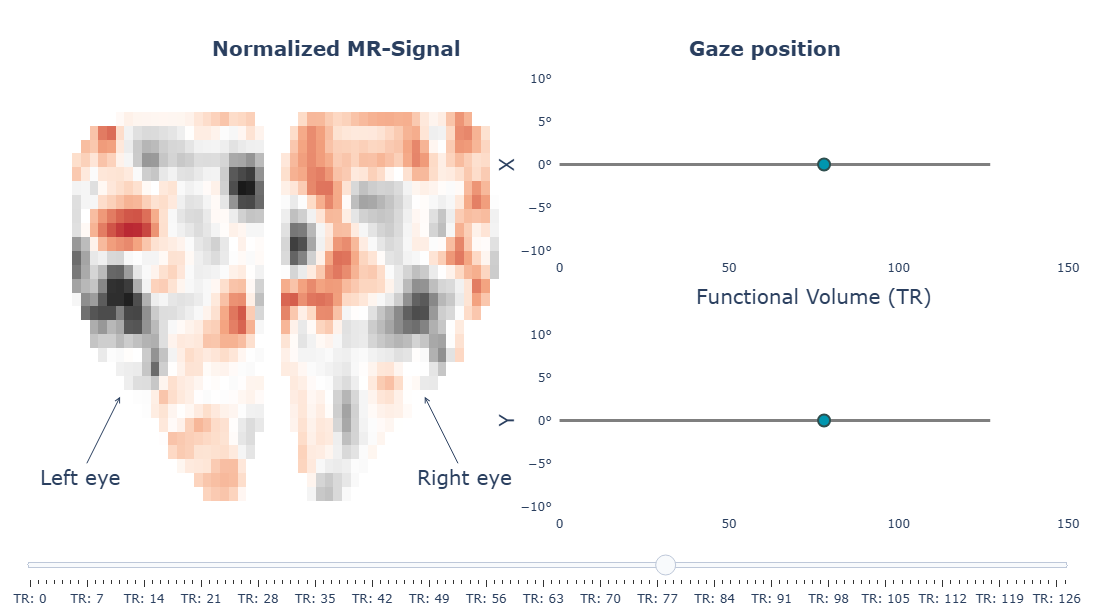

In [508]:
fig = analyse.visualise_input_data(X,
                                   y,
                                   bg_color="rgb(255,255,255)",
                                   ylim=[-11, 11])
fig.show()

# Load the old models 

In [512]:
npz_files = [f for f in os.listdir('.') if f.endswith('.npz')]
left_files = [f for f in npz_files if f.endswith('_left.npz')]
right_files = [f for f in npz_files if f.endswith('_right.npz')]
both_files = [f for f in npz_files if not (f.endswith('_left.npz') or f.endswith('_right.npz'))]


In [514]:

generators_both = data_generator.create_generators(both_files,
                                              both_files)
generators_both = (*generators_both, both_files, both_files
              )  
(model_both, model_inference_both) = train.train_model(dataset="prediction_on_stroke_both_eyes",
                                             generators=generators_both,
                                             opts=opts,
                                             return_untrained=True)
model_inference_both.load_weights('modelinference_both_eyes.h5')
(evaluation_both, scores_both) = train.evaluate_model(dataset='both_eyes', model=model_inference_both, generators=generators_both, save=False, model_description='', verbose=2, percentile_cut=80)

Training set () contains 15 subjects: 
['sub-CON005', 'sub-CON019', 'sub-CON024', 'sub-CON009', 'sub-CON003',
 'sub-CON017', 'sub-CON010', 'sub-CON012', 'sub-CON007', 'sub-CON004',
 'sub-CON014', 'sub-CON022', 'sub-CON006', 'sub-CON011', 'sub-CON002']
Test set () contains 15 subjects: 
['sub-CON005', 'sub-CON019', 'sub-CON024', 'sub-CON009', 'sub-CON003',
 'sub-CON017', 'sub-CON010', 'sub-CON012', 'sub-CON007', 'sub-CON004',
 'sub-CON014', 'sub-CON022', 'sub-CON006', 'sub-CON011', 'sub-CON002']


/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscra

1 / 15 - Model Performance for sub-CON005.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       1.672  1.281 1.231
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       1.695  1.313 1.245
Refined           NaN NaN  NaN     0.000 0.000 0.000       1.744  1.353 1.299
Refined subTR     NaN NaN  NaN     0.000 0.000 0.000       1.746  1.336 1.308


2 / 15 - Model Performance for sub-CON019.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       2.449  2.099 1.524
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       2.465  2.141 1.539
Refined           NaN NaN  NaN     0.000 0.000 0.000       2.789  2.497 1.500
Refined subTR     NaN NaN  NaN     0.000 0.000 0

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscra

3 / 15 - Model Performance for sub-CON024.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       2.695  2.490 1.543
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       2.725  2.505 1.550
Refined           NaN NaN  NaN     0.000 0.000 0.000       2.941  2.877 1.557
Refined subTR     NaN NaN  NaN     0.000 0.000 0.000       2.945  2.816 1.579


4 / 15 - Model Performance for sub-CON009.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       3.212  2.766 2.029
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       3.252  2.792 2.054
Refined           NaN NaN  NaN     0.000 0.000 0.000       3.547  3.197 2.097
Refined subTR     NaN NaN  NaN     0.000 0.000 0

...

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscra

11 / 15 - Model Performance for sub-CON014.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       2.145  1.858 1.501
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       2.165  1.894 1.510
Refined           NaN NaN  NaN     0.000 0.000 0.000       2.365  2.199 1.566
Refined subTR     NaN NaN  NaN     0.000 0.000 0.000       2.352  2.123 1.583


12 / 15 - Model Performance for sub-CON022.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       2.229  2.146 1.053
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       2.256  2.147 1.065
Refined           NaN NaN  NaN     0.000 0.000 0.000       2.469  2.367 1.020
Refined subTR     NaN NaN  NaN     0.000 0.000

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscra

13 / 15 - Model Performance for sub-CON006.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       2.927  2.241 2.137
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       2.956  2.299 2.162
Refined           NaN NaN  NaN     0.000 0.000 0.000       3.229  2.649 2.223
Refined subTR     NaN NaN  NaN     0.000 0.000 0.000       3.270  2.665 2.250


14 / 15 - Model Performance for sub-CON011.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       2.356  1.856 1.717
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       2.377  1.841 1.738
Refined           NaN NaN  NaN     0.000 0.000 0.000       2.565  2.109 1.818
Refined subTR     NaN NaN  NaN     0.000 0.000

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscra

In [515]:
fig = analyse.visualise_predictions_slider(evaluation_both, scores_both, color="rgb(0, 150, 175)", bg_color="rgb(255,255,255)", ylim=[-11, 11])
fig.show()

FigureWidget({
    'data': [{'boxpoints': 'all',
              'fillcolor': 'rgb(180, 180, 180)',
              'line': {'color': 'rgb(0,0,0)'},
              'marker': {'color': 'rgb(0, 150, 175)',
                         'line': {'color': 'rgb(0,0,0)', 'width': 2},
                         'opacity': 0.65,
                         'size': 12},
              'name': 'Default',
              'pointpos': 0,
              'text': [participant sub-CON005, participant sub-CON019, participant
                       sub-CON024, participant sub-CON009, participant sub-CON003,
                       participant sub-CON017, participant sub-CON010, participant
                       sub-CON012, participant sub-CON007, participant sub-CON004,
                       participant sub-CON014, participant sub-CON022, participant
                       sub-CON006, participant sub-CON011, participant sub-CON002,
                       participant sub-CON005, participant sub-CON019, participant
        

In [516]:
generators_left = data_generator.create_generators(left_files,
                                              left_files)
generators_left = (*generators_left, left_files, left_files
              )  
(model_left, model_inference_left) = train.train_model(dataset="prediction_on_stroke_left_eyes",
                                             generators=generators_left,
                                             opts=opts,
                                             return_untrained=True)
model_inference_left.load_weights('modelinference_left_eye.h5')
(evaluation_left, scores_left) = train.evaluate_model(dataset='left_eyes', model=model_inference_left, generators=generators_left, save=False, model_description='', verbose=2, percentile_cut=80)

Training set () contains 15 subjects: 
['sub-CON009_left', 'sub-CON012_left', 'sub-CON003_left', 'sub-CON011_left',
 'sub-CON019_left', 'sub-CON006_left', 'sub-CON004_left', 'sub-CON002_left',
 'sub-CON010_left', 'sub-CON022_left', 'sub-CON014_left', 'sub-CON024_left',
 'sub-CON005_left', 'sub-CON007_left', 'sub-CON017_left']
Test set () contains 15 subjects: 
['sub-CON009_left', 'sub-CON012_left', 'sub-CON003_left', 'sub-CON011_left',
 'sub-CON019_left', 'sub-CON006_left', 'sub-CON004_left', 'sub-CON002_left',
 'sub-CON010_left', 'sub-CON022_left', 'sub-CON014_left', 'sub-CON024_left',
 'sub-CON005_left', 'sub-CON007_left', 'sub-CON017_left']


/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscra

1 / 15 - Model Performance for sub-CON009_left.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       3.864  3.655 2.176
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       3.907  3.680 2.210
Refined           NaN NaN  NaN     0.000 0.000 0.000       4.233  4.265 2.211
Refined subTR     NaN NaN  NaN     0.000 0.000 0.000       4.260  4.213 2.252


2 / 15 - Model Performance for sub-CON012_left.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       2.941  2.677 1.725
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       2.955  2.721 1.745
Refined           NaN NaN  NaN     0.000 0.000 0.000       3.306  3.260 1.710
Refined subTR     NaN NaN  NaN     0.0

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscra

3 / 15 - Model Performance for sub-CON003_left.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       2.410  2.092 1.801
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       2.429  2.083 1.820
Refined           NaN NaN  NaN     0.000 0.000 0.000       2.689  2.366 1.894
Refined subTR     NaN NaN  NaN     0.000 0.000 0.000       2.699  2.360 1.913


4 / 15 - Model Performance for sub-CON011_left.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       2.342  1.810 1.823
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       2.368  1.787 1.846
Refined           NaN NaN  NaN     0.000 0.000 0.000       2.584  1.986 1.913
Refined subTR     NaN NaN  NaN     0.0

...

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscra

11 / 15 - Model Performance for sub-CON014_left.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       2.153  1.804 1.469
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       2.174  1.898 1.485
Refined           NaN NaN  NaN     0.000 0.000 0.000       2.341  2.242 1.558
Refined subTR     NaN NaN  NaN     0.000 0.000 0.000       2.354  2.226 1.573


12 / 15 - Model Performance for sub-CON024_left.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       1.910  1.759 1.115
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       1.933  1.794 1.134
Refined           NaN NaN  NaN     0.000 0.000 0.000       2.088  1.940 1.120
Refined subTR     NaN NaN  NaN     0

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscra

13 / 15 - Model Performance for sub-CON005_left.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       2.407  2.009 1.693
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       2.429  2.014 1.718
Refined           NaN NaN  NaN     0.000 0.000 0.000       2.681  2.380 1.732
Refined subTR     NaN NaN  NaN     0.000 0.000 0.000       2.703  2.408 1.762


14 / 15 - Model Performance for sub-CON007_left.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       2.229  1.852 1.501
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       2.248  1.851 1.516
Refined           NaN NaN  NaN     0.000 0.000 0.000       2.450  2.340 1.560
Refined subTR     NaN NaN  NaN     0

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscra

In [517]:
fig = analyse.visualise_predictions_slider(evaluation_left, scores_left, color="rgb(0, 150, 175)", bg_color="rgb(255,255,255)", ylim=[-11, 11])
fig.show()

FigureWidget({
    'data': [{'boxpoints': 'all',
              'fillcolor': 'rgb(180, 180, 180)',
              'line': {'color': 'rgb(0,0,0)'},
              'marker': {'color': 'rgb(0, 150, 175)',
                         'line': {'color': 'rgb(0,0,0)', 'width': 2},
                         'opacity': 0.65,
                         'size': 12},
              'name': 'Default',
              'pointpos': 0,
              'text': [participant sub-CON009_left, participant sub-CON012_left,
                       participant sub-CON003_left, participant sub-CON011_left,
                       participant sub-CON019_left, participant sub-CON006_left,
                       participant sub-CON004_left, participant sub-CON002_left,
                       participant sub-CON010_left, participant sub-CON022_left,
                       participant sub-CON014_left, participant sub-CON024_left,
                       participant sub-CON005_left, participant sub-CON007_left,
                      

In [518]:

generators_right = data_generator.create_generators(right_files,
                                              right_files)
generators_right = (*generators_right, right_files, right_files
              )  
(model_right, model_inference_right) = train.train_model(dataset="prediction_on_stroke_right_eyes",
                                             generators=generators_right,
                                             opts=opts,
                                             return_untrained=True)
model_inference_right.load_weights('modelinference_right_eye.h5')
(evaluation_right, scores_right) = train.evaluate_model(dataset='right_eyes', model=model_inference_right, generators=generators_right, save=False, model_description='', verbose=2, percentile_cut=80)

Training set () contains 15 subjects: 
['sub-CON014_right', 'sub-CON019_right', 'sub-CON004_right', 'sub-CON006_right',
 'sub-CON007_right', 'sub-CON009_right', 'sub-CON012_right', 'sub-CON005_right',
 'sub-CON003_right', 'sub-CON002_right', 'sub-CON022_right', 'sub-CON010_right',
 'sub-CON011_right', 'sub-CON024_right', 'sub-CON017_right']
Test set () contains 15 subjects: 
['sub-CON014_right', 'sub-CON019_right', 'sub-CON004_right', 'sub-CON006_right',
 'sub-CON007_right', 'sub-CON009_right', 'sub-CON012_right', 'sub-CON005_right',
 'sub-CON003_right', 'sub-CON002_right', 'sub-CON022_right', 'sub-CON010_right',
 'sub-CON011_right', 'sub-CON024_right', 'sub-CON017_right']


/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscra

1 / 15 - Model Performance for sub-CON014_right.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       2.755  2.289 1.901
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       2.774  2.316 1.924
Refined           NaN NaN  NaN     0.000 0.000 0.000       2.980  2.499 1.986
Refined subTR     NaN NaN  NaN     0.000 0.000 0.000       3.016  2.584 2.000


2 / 15 - Model Performance for sub-CON019_right.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       2.650  2.270 1.983
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       2.684  2.318 2.023
Refined           NaN NaN  NaN     0.000 0.000 0.000       2.842  2.600 2.136
Refined subTR     NaN NaN  NaN     0

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscra

3 / 15 - Model Performance for sub-CON004_right.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       3.984  3.934 2.227
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       3.996  3.931 2.248
Refined           NaN NaN  NaN     0.000 0.000 0.000       4.396  4.325 2.214
Refined subTR     NaN NaN  NaN     0.000 0.000 0.000       4.381  4.237 2.253


4 / 15 - Model Performance for sub-CON006_right.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       2.353  1.772 1.886
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       2.371  1.839 1.912
Refined           NaN NaN  NaN     0.000 0.000 0.000       2.649  2.195 1.976
Refined subTR     NaN NaN  NaN     0

...

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscra

11 / 15 - Model Performance for sub-CON022_right.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       1.362  1.026 1.016
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       1.363  1.043 1.026
Refined           NaN NaN  NaN     0.000 0.000 0.000       1.405  1.090 1.087
Refined subTR     NaN NaN  NaN     0.000 0.000 0.000       1.402  1.081 1.097


12 / 15 - Model Performance for sub-CON010_right.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       1.820  1.335 1.370
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       1.829  1.346 1.389
Refined           NaN NaN  NaN     0.000 0.000 0.000       2.058  1.599 1.428
Refined subTR     NaN NaN  NaN    

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscra

13 / 15 - Model Performance for sub-CON011_right.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       1.433  1.086 1.160
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       1.441  1.075 1.180
Refined           NaN NaN  NaN     0.000 0.000 0.000       1.499  1.108 1.231
Refined subTR     NaN NaN  NaN     0.000 0.000 0.000       1.495  1.107 1.240


14 / 15 - Model Performance for sub-CON024_right.npz
              Pearson          R^2-Score             Eucl. Error             
                    X   Y Mean         X     Y  Mean        Mean Median   Std
Default           NaN NaN  NaN     0.000 0.000 0.000       3.359  3.369 2.037
Default subTR     NaN NaN  NaN     0.000 0.000 0.000       3.382  3.372 2.062
Refined           NaN NaN  NaN     0.000 0.000 0.000       3.590  3.757 2.126
Refined subTR     NaN NaN  NaN    

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning:

invalid value encountered in divide

/net/tscratch/people/plgkoba/venvs/deepmreye-gpu/lib/python3.10/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning:

invalid value encountered in divide

/net/tscra

In [519]:
fig = analyse.visualise_predictions_slider(evaluation_right, scores_right, color="rgb(0, 150, 175)", bg_color="rgb(255,255,255)", ylim=[-11, 11])
fig.show()

FigureWidget({
    'data': [{'boxpoints': 'all',
              'fillcolor': 'rgb(180, 180, 180)',
              'line': {'color': 'rgb(0,0,0)'},
              'marker': {'color': 'rgb(0, 150, 175)',
                         'line': {'color': 'rgb(0,0,0)', 'width': 2},
                         'opacity': 0.65,
                         'size': 12},
              'name': 'Default',
              'pointpos': 0,
              'text': [participant sub-CON014_right, participant sub-CON019_right,
                       participant sub-CON004_right, participant sub-CON006_right,
                       participant sub-CON007_right, participant sub-CON009_right,
                       participant sub-CON012_right, participant sub-CON005_right,
                       participant sub-CON003_right, participant sub-CON002_right,
                       participant sub-CON022_right, participant sub-CON010_right,
                       participant sub-CON011_right, participant sub-CON024_right,
        

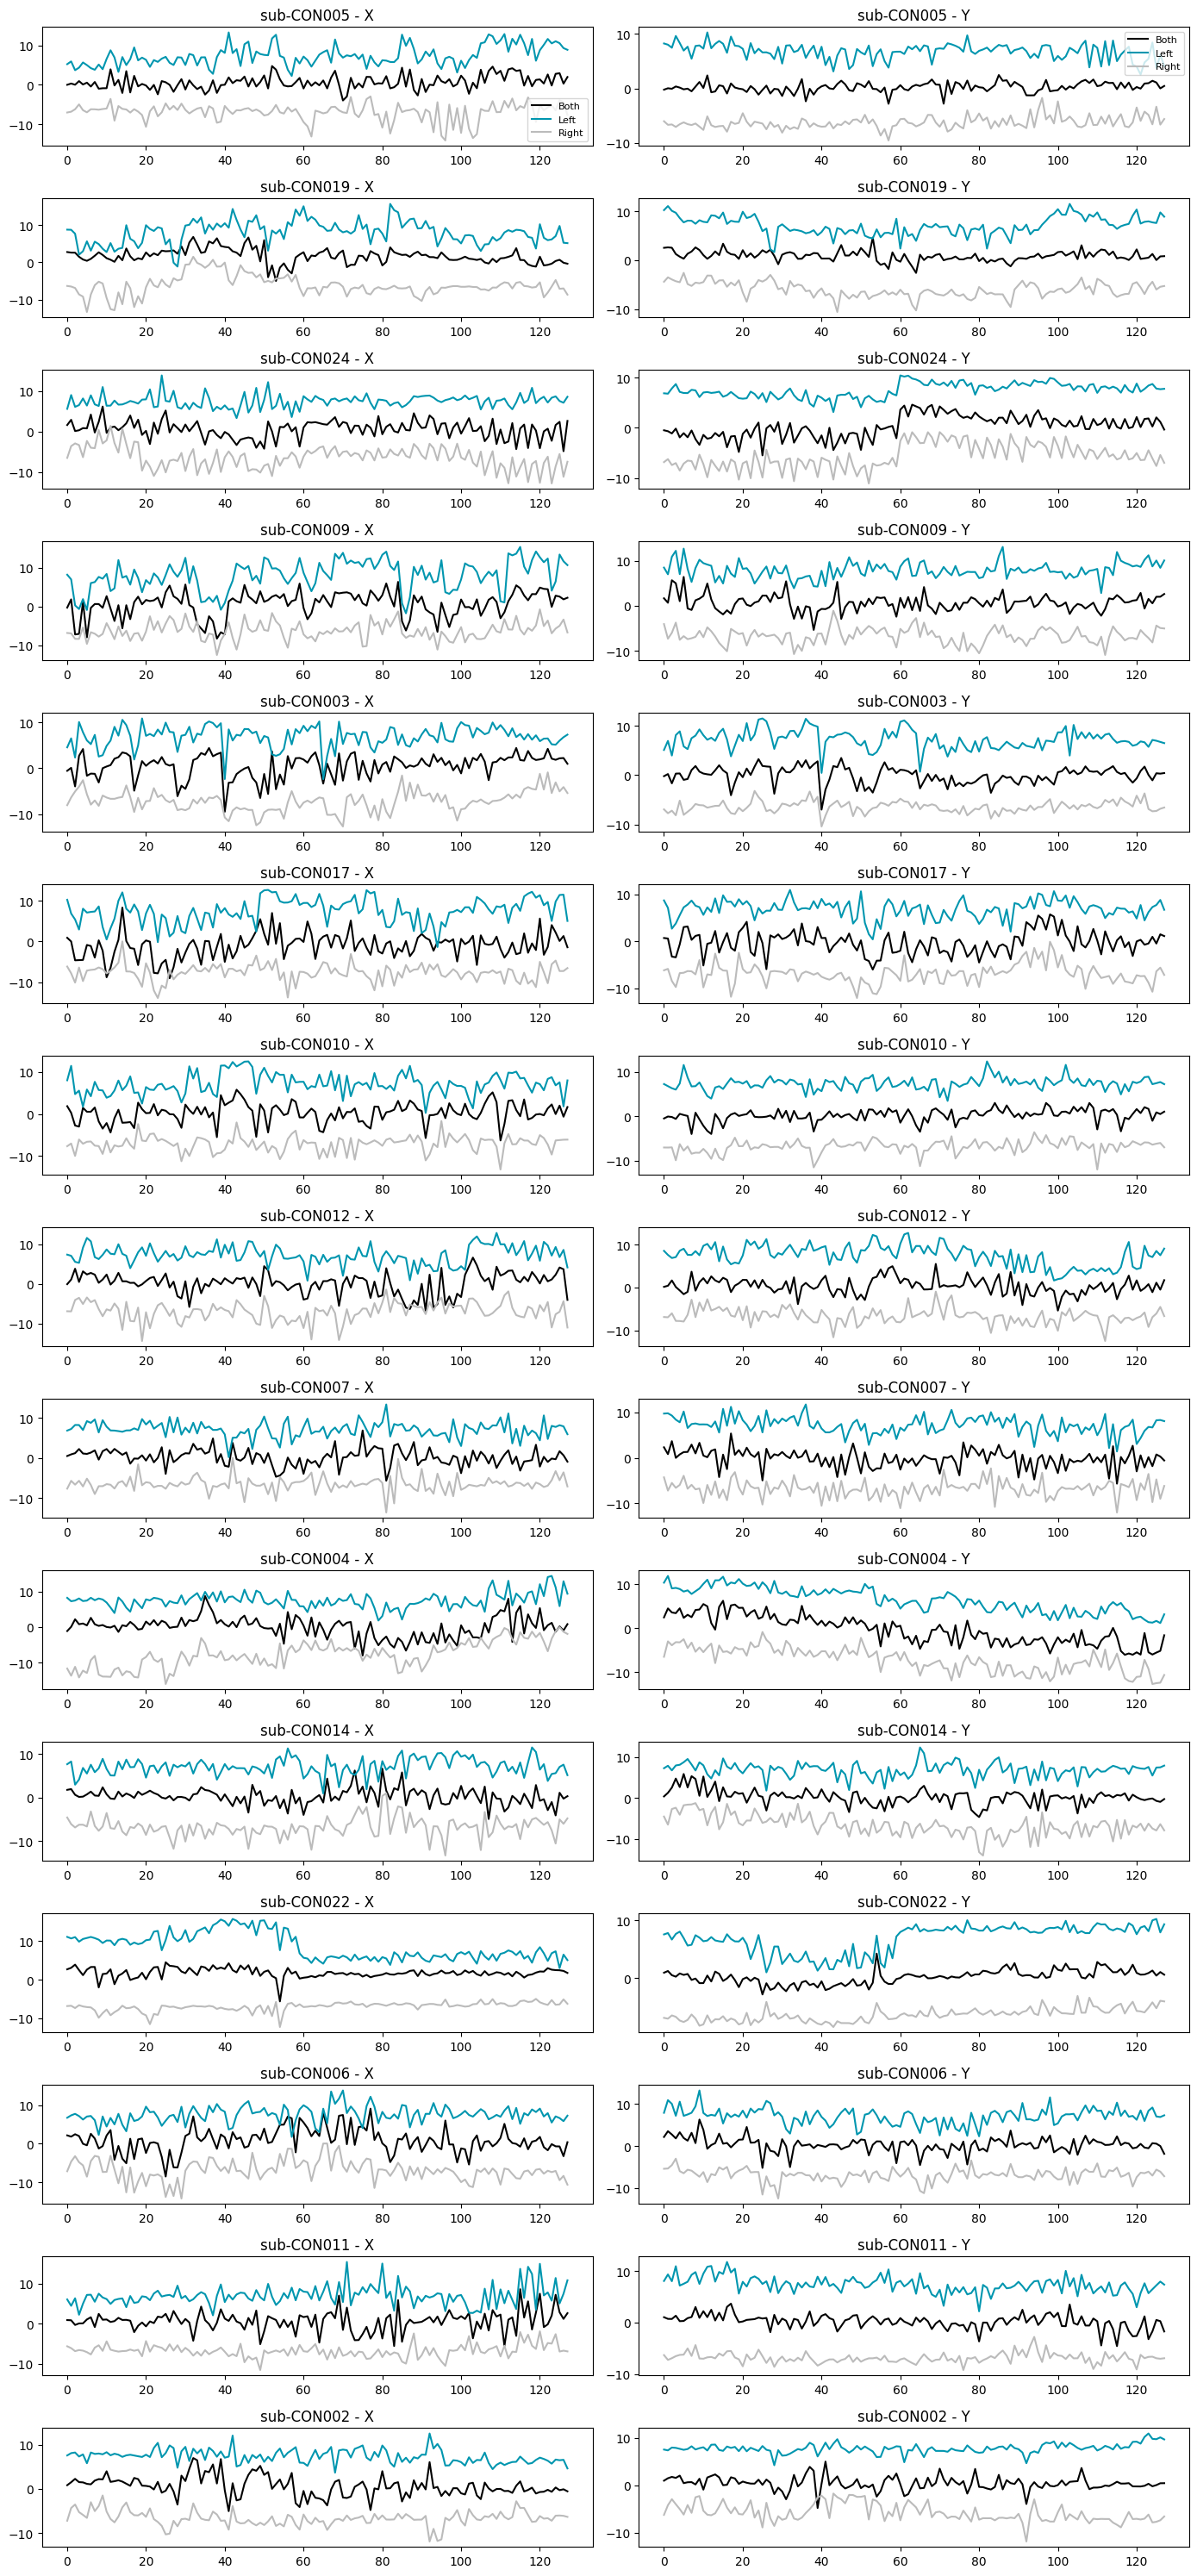

In [526]:
import numpy as np
import matplotlib.pyplot as plt
# Define colors (convert RGB 0-255 to 0-1)
both_color = (0/255, 0/255, 0/255)
left_color = (0/255, 150/255, 175/255) 
right_color = (187/255, 187/255, 187/255)
subjects = [key.replace('.npz', '') for key in evaluation_both.keys()]

# Adjust figure height for 15 subjects (15 rows × 2 columns)
plt.figure(figsize=(14, 30))

for i, subj in enumerate(subjects):
    # Reduce to (128, 2)
    y_both = np.median(evaluation_both[f"{subj}.npz"]['pred_y'], axis=1)
    y_left = np.median(evaluation_left[f"{subj}_left.npz"]['pred_y'], axis=1)
    y_right = np.median(evaluation_right[f"{subj}_right.npz"]['pred_y'], axis=1)

    # Column 0 subplot (X)
    plt.subplot(len(subjects), 2, 2*i+1)
    plt.plot(y_both[:, 0], label="Both",color=both_color)
    plt.plot(y_left[:, 0]+7, label="Left",color=left_color)
    plt.plot(y_right[:, 0]-7, label="Right",color=right_color)
    plt.title(f"{subj} - X")
    if i == 0:
        plt.legend(fontsize=8)

    # Column 1 subplot (Y)
    plt.subplot(len(subjects), 2, 2*i+2)
    plt.plot(y_both[:, 1], label="Both",color=both_color)
    plt.plot(y_left[:, 1]+7, label="Left",color=left_color)
    plt.plot(y_right[:, 1]-7, label="Right",color=right_color)
    plt.title(f"{subj} - Y")
    if i == 0:
        plt.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [524]:
import numpy as np

def r2_score(y_true, y_pred):
    """Compute R² between two 1D arrays"""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

subjects = evaluation_both.keys()
results = {}

for subj_key in subjects:
    subj_name = subj_key.replace('.npz', '')

    # Reduce to (128, 2)
    y_both = np.median(evaluation_both[subj_key]['pred_y'], axis=1)
    y_left = np.median(evaluation_left[f"{subj_name}_left.npz"]['pred_y'], axis=1)
    y_right = np.median(evaluation_right[f"{subj_name}_right.npz"]['pred_y'], axis=1)

    metrics_col0 = {}
    metrics_col1 = {}

    # Pairwise comparisons
    pairs = [('Both', y_both), ('Left', y_left), ('Right', y_right)]
    for i in range(len(pairs)):
        for j in range(i+1, len(pairs)):
            name = f"{pairs[i][0]}-{pairs[j][0]}"
            # Column 0
            metrics_col0[name] = {
                'corr': np.corrcoef(pairs[i][1][:, 0], pairs[j][1][:, 0])[0, 1],
                'R2': r2_score(pairs[i][1][:, 0], pairs[j][1][:, 0])
            }
            # Column 1
            metrics_col1[name] = {
                'corr': np.corrcoef(pairs[i][1][:, 1], pairs[j][1][:, 1])[0, 1],
                'R2': r2_score(pairs[i][1][:, 1], pairs[j][1][:, 1])
            }

    results[subj_name] = {'col0': metrics_col0, 'col1': metrics_col1}

# Print results
for subj, res in results.items():
    print(f"{subj}:")
    print(f"  col0:")
    for pair, metrics in res['col0'].items():
        print(f"    {pair} - corr: {metrics['corr']:.3f}, R2: {metrics['R2']:.3f}")
    print(f"  col1:")
    for pair, metrics in res['col1'].items():
        print(f"    {pair} - corr: {metrics['corr']:.3f}, R2: {metrics['R2']:.3f}")
    print()


sub-CON005:
  col0:
    Both-Left - corr: 0.471, R2: -0.727
    Both-Right - corr: 0.274, R2: -0.982
    Left-Right - corr: 0.200, R2: -0.428
  col1:
    Both-Left - corr: 0.301, R2: -1.961
    Both-Right - corr: 0.171, R2: -1.533
    Left-Right - corr: -0.161, R2: -1.287

sub-CON019:
  col0:
    Both-Left - corr: 0.336, R2: -1.482
    Both-Right - corr: 0.420, R2: -0.904
    Left-Right - corr: 0.330, R2: -0.198
  col1:
    Both-Left - corr: 0.384, R2: -2.631
    Both-Right - corr: 0.413, R2: -0.905
    Left-Right - corr: 0.381, R2: -0.265

sub-CON024:
  col0:
    Both-Left - corr: 0.224, R2: -0.209
    Both-Right - corr: 0.544, R2: -0.221
    Left-Right - corr: -0.009, R2: -3.001
  col1:
    Both-Left - corr: 0.727, R2: 0.512
    Both-Right - corr: 0.820, R2: 0.327
    Left-Right - corr: 0.668, R2: -1.078

sub-CON009:
  col0:
    Both-Left - corr: 0.780, R2: 0.426
    Both-Right - corr: 0.629, R2: 0.393
    Left-Right - corr: 0.411, R2: 0.137
  col1:
    Both-Left - corr: 0.623, R2: 0

In [523]:
df

,Subject,Column,Pair,Corr,R2
0,sub-CON005,X,Both-Left,0.471,-0.727
1,sub-CON005,Y,Both-Left,0.301,-1.961
2,sub-CON005,X,Both-Right,0.274,-0.982
3,sub-CON005,Y,Both-Right,0.171,-1.533
4,sub-CON005,X,Left-Right,0.200,-0.428
...,...,...,...,...,...
85,sub-CON002,Y,Both-Left,0.386,-0.042
86,sub-CON002,X,Both-Right,0.235,-0.194
87,sub-CON002,Y,Both-Right,0.217,-1.585
88,sub-CON002,X,Left-Right,-0.103,-1.427
